<a href="https://colab.research.google.com/github/lena-33/Prediction_of_Product_Sales/blob/main/Prediction_of_Product_Sales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Prediction of Product Sales
 - Author: Lina Thabet


## Project Overview

## Load and Inspect Data

In [ ]:
import pandas as pd

In [ ]:
path = "/content/drive/MyDrive/AXSOSACADEMY/01-Fundamentals/Week02/Data/sales_predictions_2023.csv"
df = pd.read_csv(path)

In [ ]:
df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


## Clean Data

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.isna().sum()

,0
Item_Identifier,0
Item_Weight,1463
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,2410
Outlet_Location_Type,0


In [ ]:
df.isna().sum() / len(df) * 100

,0
Item_Identifier,0.000000
Item_Weight,17.165317
Item_Fat_Content,0.000000
Item_Visibility,0.000000
Item_Type,0.000000
Item_MRP,0.000000
Outlet_Identifier,0.000000
Outlet_Establishment_Year,0.000000
Outlet_Size,28.276428
Outlet_Location_Type,0.000000


In [ ]:
df['Item_Weight'].describe()

,Item_Weight
count,7060.000000
mean,12.857645
std,4.643456
min,4.555000
25%,8.773750
50%,12.600000
75%,16.850000
max,21.350000


In [ ]:
med = df['Item_Weight'].median()

In [ ]:
df['Item_Weight'] = df['Item_Weight'].replace(-1, med)

In [ ]:
df['Item_Weight'].value_counts()

,count
Item_Weight,
12.150,86
17.600,82
13.650,77
11.800,76
15.100,68
...,...
8.920,2
6.520,1
9.420,1


In [ ]:
df['Item_Weight'].isna().sum()

np.int64(1463)

In [ ]:
df['Outlet_Size'] = df['Outlet_Size'].fillna(-1)

In [ ]:
df['Outlet_Size'].isna().sum()

np.int64(0)

In [ ]:
string_col = df.select_dtypes('object').columns
string_col

Index(['Item_Identifier', 'Item_Fat_Content', 'Item_Type', 'Outlet_Identifier',
       'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type'],
      dtype='object')

In [ ]:
for i in string_col:
  print('The column :', df[i].value_counts() , '\n')

The column : Item_Identifier
FDW13    10
FDG33    10
FDX31     9
FDT07     9
NCY18     9
         ..
FDO33     1
FDK57     1
FDT35     1
FDN52     1
FDE52     1
Name: count, Length: 1559, dtype: int64 

The column : Item_Fat_Content
Low Fat    5089
Regular    2889
LF          316
reg         117
low fat     112
Name: count, dtype: int64 

The column : Item_Type
Fruits and Vegetables    1232
Snack Foods              1200
Household                 910
Frozen Foods              856
Dairy                     682
Canned                    649
Baking Goods              648
Health and Hygiene        520
Soft Drinks               445
Meat                      425
Breads                    251
Hard Drinks               214
Others                    169
Starchy Foods             148
Breakfast                 110
Seafood                    64
Name: count, dtype: int64 

The column : Outlet_Identifier
OUT027    935
OUT013    932
OUT035    930
OUT049    930
OUT046    930
OUT045    929
OUT018    928

In [ ]:
df['Item_Fat_Content'] = df['Item_Fat_Content'].replace('LF','Low Fat')

In [ ]:
df['Item_Fat_Content'] = df['Item_Fat_Content'].replace('reg','Regular')

In [ ]:
df['Item_Fat_Content'] = df['Item_Fat_Content'].replace('low fat','Low Fat')

In [ ]:
df['Item_Fat_Content'].value_counts()

,count
Item_Fat_Content,
Low Fat,5517
Regular,3006


In [ ]:
number_col = df.select_dtypes('number').columns
number_col

Index(['Item_Weight', 'Item_Visibility', 'Item_MRP',
       'Outlet_Establishment_Year', 'Item_Outlet_Sales'],
      dtype='object')

In [ ]:
for i in number_col:
  print(f'The column :{i}\n', df[i].describe() , '\n')

The column :Item_Weight
 count    7060.000000
mean       12.857645
std         4.643456
min         4.555000
25%         8.773750
50%        12.600000
75%        16.850000
max        21.350000
Name: Item_Weight, dtype: float64 

The column :Item_Visibility
 count    8523.000000
mean        0.066132
std         0.051598
min         0.000000
25%         0.026989
50%         0.053931
75%         0.094585
max         0.328391
Name: Item_Visibility, dtype: float64 

The column :Item_MRP
 count    8523.000000
mean      140.992782
std        62.275067
min        31.290000
25%        93.826500
50%       143.012800
75%       185.643700
max       266.888400
Name: Item_MRP, dtype: float64 

The column :Outlet_Establishment_Year
 count    8523.000000
mean     1997.831867
std         8.371760
min      1985.000000
25%      1987.000000
50%      1999.000000
75%      2004.000000
max      2009.000000
Name: Outlet_Establishment_Year, dtype: float64 

The column :Item_Outlet_Sales
 count     8523.000000
m

In [ ]:
df.describe().round(2)

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,7060.00,8523.00,8523.00,8523.00,8523.00
mean,12.86,0.07,140.99,1997.83,2181.29
std,4.64,0.05,62.28,8.37,1706.50
min,4.56,0.00,31.29,1985.00,33.29
25%,8.77,0.03,93.83,1987.00,834.25
50%,12.60,0.05,143.01,1999.00,1794.33
75%,16.85,0.09,185.64,2004.00,3101.30
max,21.35,0.33,266.89,2009.00,13086.96


## Exploratory Data Analysis

In [ ]:
df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,-1,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [ ]:
df.select_dtypes('number').columns

Index(['Item_Weight', 'Item_Visibility', 'Item_MRP',
       'Outlet_Establishment_Year', 'Item_Outlet_Sales'],
      dtype='object')

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

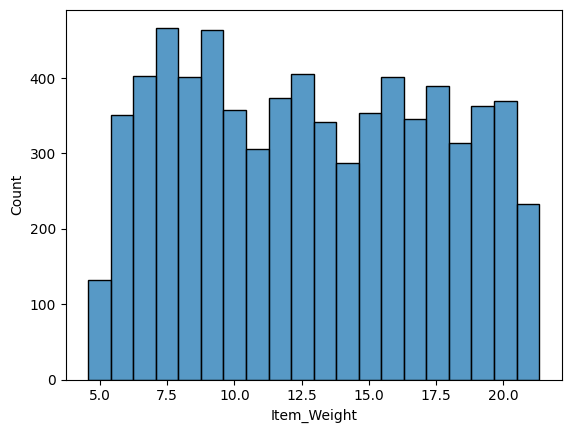

In [ ]:
sns.histplot(data=df , x='Item_Weight');

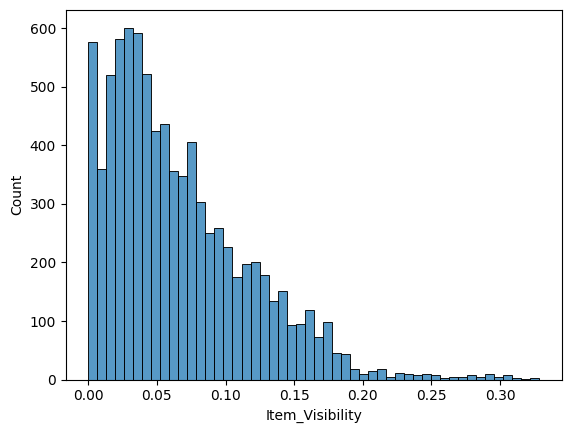

In [ ]:
sns.histplot(data=df , x='Item_Visibility');

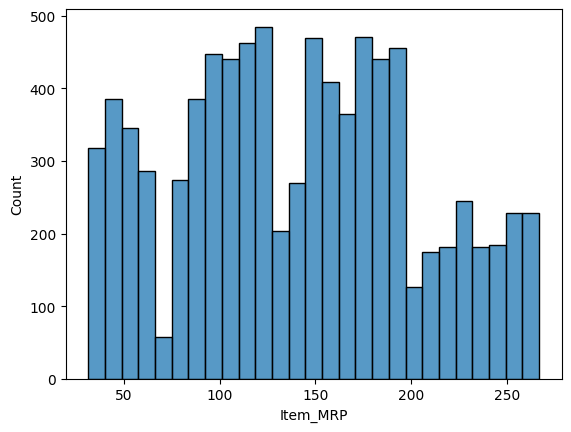

In [ ]:
sns.histplot(data=df , x='Item_MRP');

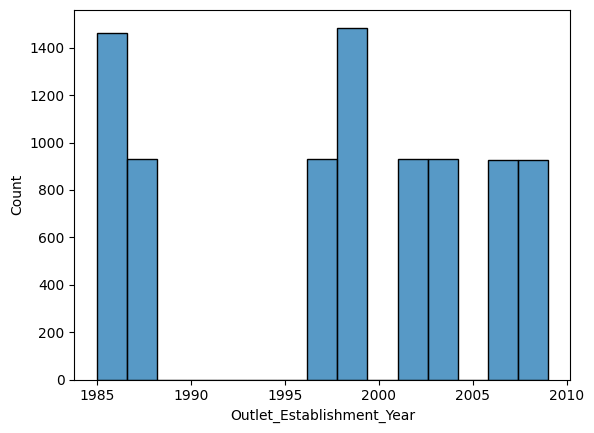

In [ ]:
sns.histplot(data=df , x='Outlet_Establishment_Year');

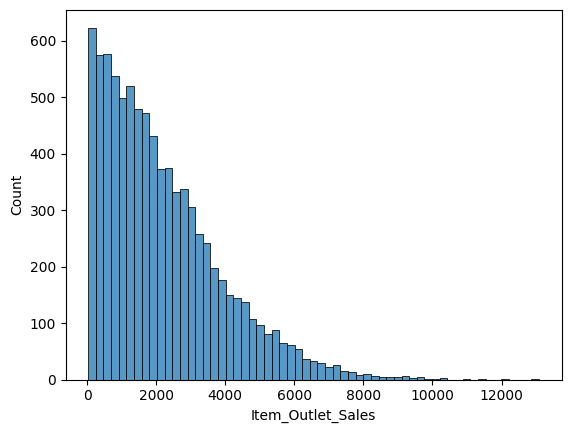

In [ ]:
sns.histplot(data=df , x='Item_Outlet_Sales');

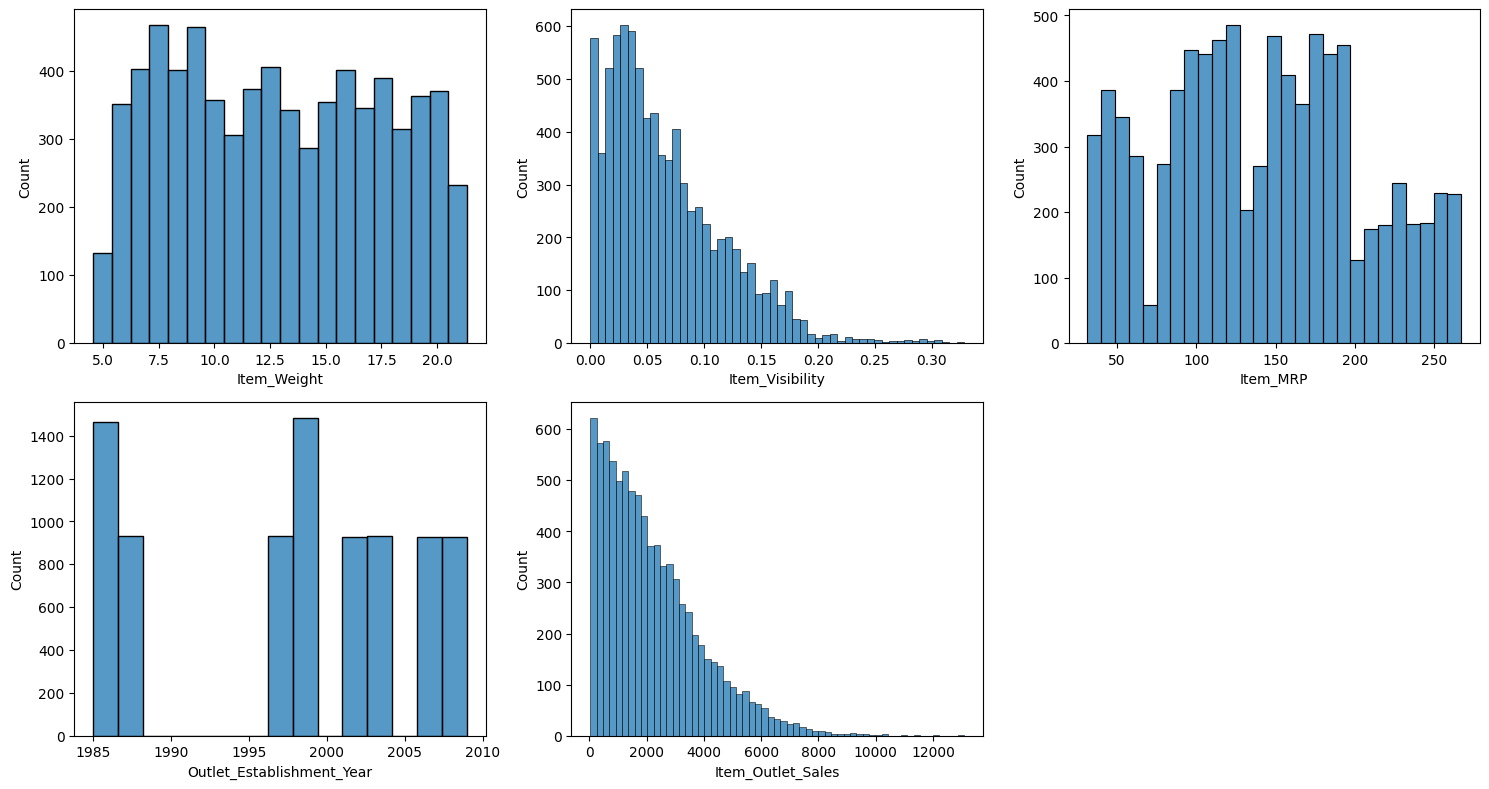

In [ ]:
fig, axes = plt.subplots(ncols=3 , nrows=2, figsize=(15, 8))
sns.histplot(data=df , x='Item_Weight',ax=axes[0,0])
sns.histplot(data=df , x='Item_Visibility',ax=axes[0,1])
sns.histplot(data=df , x='Item_MRP',ax=axes[0,2])
sns.histplot(data=df , x='Outlet_Establishment_Year',ax=axes[1,0])
sns.histplot(data=df , x='Item_Outlet_Sales',ax=axes[1,1])

# Remove the unused 6th subplot
fig.delaxes(axes[1,2])

fig.tight_layout();

- This set of histograms displays the distribution of several numerical features: 'Item_Weight', 'Item_Visibility', 'Item_MRP', 'Outlet_Establishment_Year', and 'Item_Outlet_Sales'. These plots help to understand the shape of the data, central tendency, and spread for each variable.

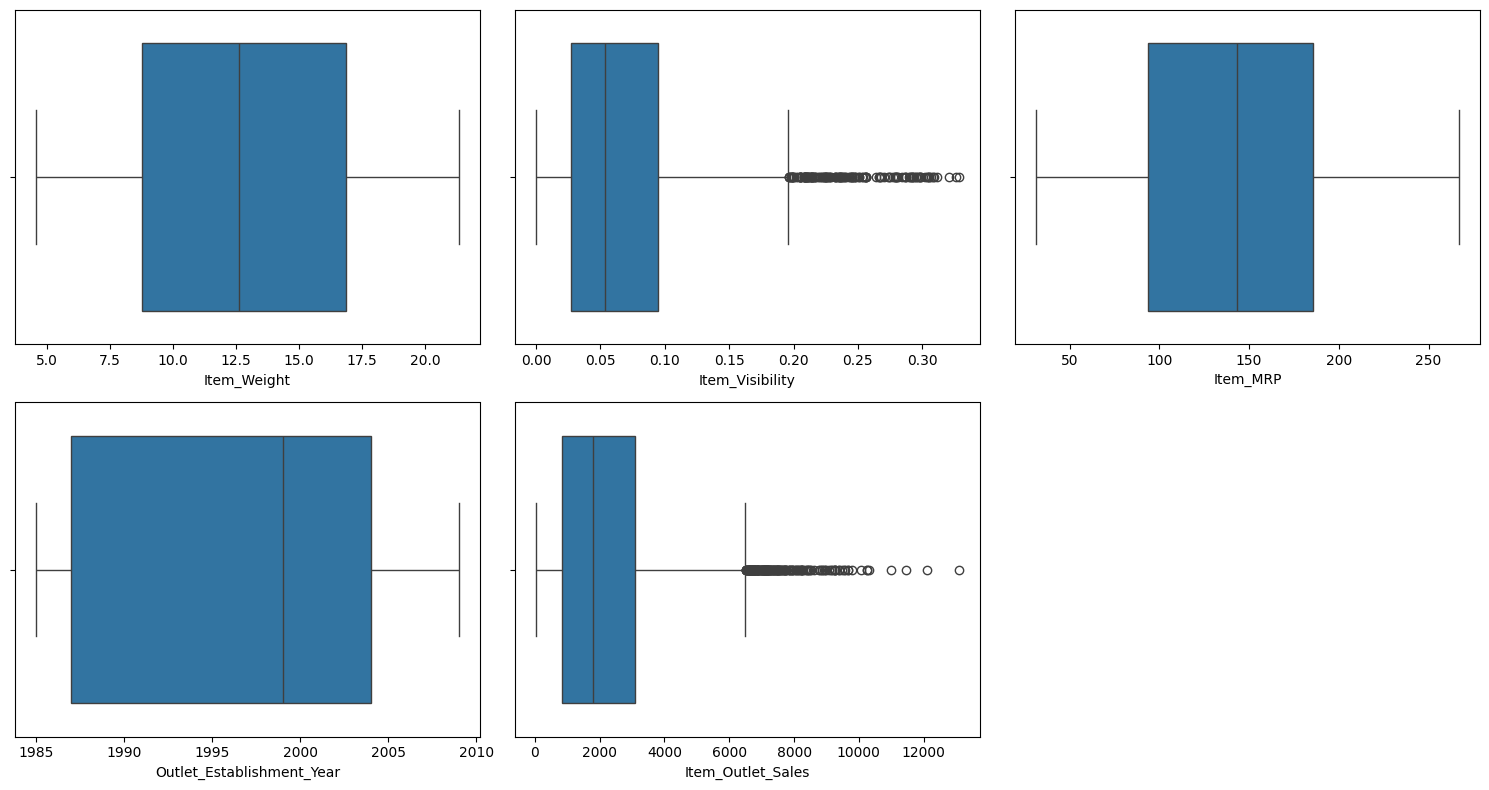

In [ ]:
fig, axes = plt.subplots(ncols=3 , nrows=2, figsize=(15, 8))
sns.boxplot(data=df , x='Item_Weight',ax=axes[0,0])
sns.boxplot(data=df , x='Item_Visibility',ax=axes[0,1])
sns.boxplot(data=df , x='Item_MRP',ax=axes[0,2])
sns.boxplot(data=df , x='Outlet_Establishment_Year',ax=axes[1,0])
sns.boxplot(data=df , x='Item_Outlet_Sales',ax=axes[1,1])

fig.delaxes(axes[1,2])

fig.tight_layout();

- This set of boxplots visualizes the distribution and potential outliers for numerical features: 'Item_Weight', 'Item_Visibility', 'Item_MRP', 'Outlet_Establishment_Year', and 'Item_Outlet_Sales'. Boxplots provide a good summary of the five-number summary (minimum, first quartile, median, third quartile, and maximum) and highlight any extreme values.

In [ ]:
df.select_dtypes('object').columns

Index(['Item_Identifier', 'Item_Fat_Content', 'Item_Type', 'Outlet_Identifier',
       'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type'],
      dtype='object')

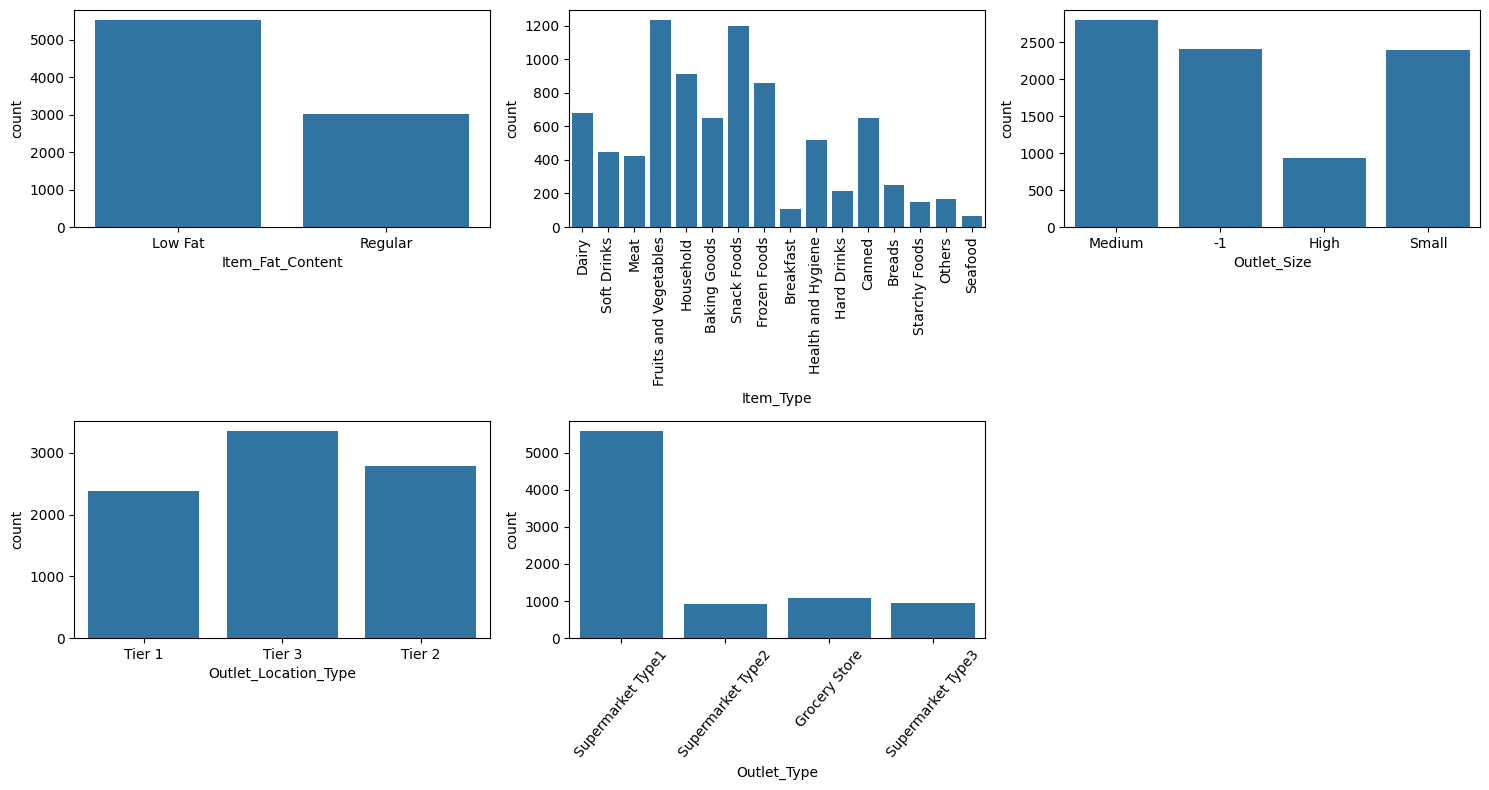

In [ ]:
fig, axes = plt.subplots(ncols=3 , nrows=2, figsize=(15, 8))
sns.countplot(data=df , x='Item_Fat_Content',ax=axes[0,0])
sns.countplot(data=df , x='Item_Type',ax=axes[0,1])
axes[0,1].tick_params(axis='x' , rotation=90)
sns.countplot(data=df , x='Outlet_Size',ax=axes[0,2])
sns.countplot(data=df , x='Outlet_Location_Type',ax=axes[1,0])
sns.countplot(data=df , x='Outlet_Type',ax=axes[1,1])
axes[1,1].tick_params(axis='x' , rotation=50)


fig.delaxes(axes[1,2])

fig.tight_layout();

- This set of countplots shows the frequency distribution of categorical features: 'Item_Fat_Content', 'Item_Type', 'Outlet_Size', 'Outlet_Location_Type', and 'Outlet_Type'. These plots illustrate the number of occurrences for each category within these features.

In [ ]:
corr = df.corr(numeric_only=True)
corr.round(2)

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
Item_Weight,1.00,-0.01,0.03,-0.01,0.01
Item_Visibility,-0.01,1.00,-0.00,-0.07,-0.13
Item_MRP,0.03,-0.00,1.00,0.01,0.57
Outlet_Establishment_Year,-0.01,-0.07,0.01,1.00,-0.05
Item_Outlet_Sales,0.01,-0.13,0.57,-0.05,1.00


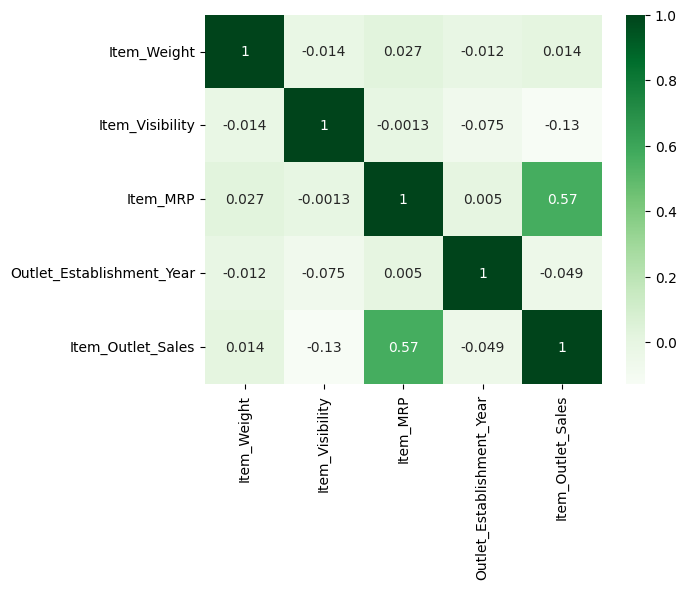

In [ ]:
sns.heatmap(corr , annot=True , cmap='Greens');

- We can see their is a positive correlation between 'Item_MRP' & 'Item_Outlet_Sales'.

## Feature inspection